In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from tqdm.auto import tqdm
from pd_estim_A.data.data_import import (
    load_data, load_ecb_1y_yield,
    fill_liabilities, drop_high_leverage_firms,
    prepare_merton_inputs, prepare_nig_inputs
)
from pd_estim_A.data.cds_df import get_cds_panel
from pd_estim_A.models.nig.nig_apath import (
    NIGParams,
    build_weekly_calendar_from_panel,
    solve_esscher_theta,
    call_nig_with_theta,
    invert_assets_weekly_for_firm,
)

from pd_estim_A.models.nig.nig_em import (
    em_fit_nig,
    fit_nig_params_from_weekly_assets,
    project_delta_to_sample_var,
    project_mu_to_sample_mean,
    nig_mean_one_step,
    nig_var_one_step,
)

from pd_estim_A.models.nig.nig_pd import (
    pd_terminal_nig_weekly,
    pd_weekly_one_firm,
)

# Single-firm feasibility settings
WEEK_ENDING = "W-FRI"
T_INV = 1.0                 # 1-year pricing horizon in inversion
HORIZON_WEEKS = 52.0        # 1-year PD horizon in weekly units

EM_MAX_ITER = 80
EM_TOL = 1e-6

# Practical regularization choice for inversion seed / final fit
ALPHA_SEED_MIN = 2.25
ALPHA_MIN_FINAL = 2.25
ESSCHER_MARGIN = 0.25

# Numerics
INVERT_U = 120.0
INVERT_N = 2000

c:\Users\vkeenan\AppData\Local\miniconda3\envs\Accenture\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### note
The rolling NIG implementation is numerically stable, but the tail-shape parameter is only weakly identified. Consequently, the estimated model should be interpreted as a regularized NIG benchmark, and sensitivity to the lower bound on alpha must be reported. 

We use primarily alpha_min = 1.75 as the main specification and report 1.25, 2.5, and 3.0 as sensitivity cases. We do not use 3.0 as the headline model, because it is fully floor-bound and therefore too close to “fixed-alpha regularization.” Also 1.25 is not used as main specification, because it is still floor-bound in 92.5% of windows and is very close to the minimum admissible region. 1.75 is the best compromise in the current setup: it is stable on the subset, it allows at least a little movement above the floor, and it keeps the model more distinctly non-Gaussian than 2.5 or 3.0.

In [2]:
# Paths
print(Path.cwd())
data_path = Path.cwd() / ".." / "data" / "raw"
output_path = Path.cwd() / ".." / "data" / "derived"

# Load data and prepare panels
ret_daily, bs, coverage = load_data(
    data_path / "Jan2025_Accenture_Dataset_ErasmusCase.xlsx",
    start_date="2012-01-01",
    end_date="2025-12-19",
    enforce_coverage=True,
    coverage_tol=0.995,
    liabilities_scale="auto",
    verbose=True,
)

df_rf = load_ecb_1y_yield(
    startPeriod="2010-01-01",
    endPeriod="2025-12-31",
    out_file= output_path / "ecb_yc_1y_aaa.xml",
    verify_ssl=True,  # recommended if it works
)

df_cal = ret_daily[["date"]].drop_duplicates().sort_values("date").reset_index(drop=True)

debt_daily = fill_liabilities(bs, df_cal)

ret_filt, bs_filt, lev_by_firm, dropped = drop_high_leverage_firms(
    ret_daily,
    bs,
    df_calendar=df_cal,
    debt_daily=debt_daily,
    lev_threshold=8.0,
    lev_agg="median",
    verbose=True,
)

# keep debt panel consistent with filtered firms
keep = set(ret_filt["gvkey"].astype(str).unique())
debt_daily_filt = debt_daily[debt_daily["gvkey"].astype(str).isin(keep)].copy()


nig_df, em_cache = prepare_nig_inputs(ret_filt, bs_filt, df_rf, debt_daily=debt_daily_filt, build_em=False)
print(nig_df.head())
print(nig_df.shape)
print(nig_df.describe())

c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_clean
[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
Data has been written to c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_clean\..\data\derived\ecb_yc_1y_aaa.xml
[drop_high_leverage_firms] agg=median, threshold=8.0
[drop_high_leverage_firms] firms before: 46 | after: 36
[drop_high_leverage_firms] dropped firms: 10
    gvkey       date             E          isin  \
0  100022 2012-01-03  3.328431e+10  DE0005190003   
1  100080 2012-01-03  4.268705e+10  DE000BAY0017   
2  100312 2012-01-03  1.469717e+09  DE0007030009   
3  100581 2012-01-03  4.935351e+10  FR0000120321   
4  100957 2012-01-03  2.9

In [3]:
# call cds panel and merge
cds = get_cds_panel(
    project_root= Path.cwd() / "..",
    save_csv=False,
    verbose=True,
)
# ensure types
nig = nig_df.copy()
nig["gvkey"] = nig["gvkey"].astype(str)
nig["date"]  = pd.to_datetime(nig["date"])

cds["gvkey"] = cds["gvkey"].astype(str)
cds["date"]  = pd.to_datetime(cds["date"])

# keep only firms that exist in BOTH (drop firms with no CDS)
common_gv = sorted(set(nig["gvkey"].unique()) & set(cds["gvkey"].unique()))
nig = nig[nig["gvkey"].isin(common_gv)].copy()
cds = cds[cds["gvkey"].isin(common_gv)].copy()

# also drop CDS rows whose dates are outside merged's date range
dmin, dmax = nig["date"].min(), nig["date"].max()
cds = cds[(cds["date"] >= dmin) & (cds["date"] <= dmax)].copy()

# merge-asof onto merged's dates (direction='backward')
nig = nig.sort_values(["date", "gvkey"]).reset_index(drop=True)
cds    = cds.sort_values(["date", "gvkey"]).reset_index(drop=True)

merged_cds = pd.merge_asof(
    nig,
    cds,
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

nig_df = merged_cds.reset_index(drop=True)

print("firms after intersection:", nig_df["gvkey"].nunique())
print("rows after merge:", len(nig_df))
print("date range:", nig_df["date"].min(), "→", nig_df["date"].max())

[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
[get_cds_panel] sheets read: 22 | rows parsed: 67015 | unmapped sheets: 0
firms after intersection: 21
rows after merge: 76508
date range: 2012-01-03 00:00:00 → 2025-12-19 00:00:00


In [4]:
# reproducible random choice
rng = np.random.default_rng(42)

unique_gvkeys = np.sort(nig_df["gvkey"].astype(str).dropna().unique())
test_gvkey = rng.choice(unique_gvkeys)

nig_df_onefirm = (
    nig_df.loc[nig_df["gvkey"].astype(str) == str(test_gvkey)]
          .copy()
          .sort_values("date")
          .reset_index(drop=True)
)

print("chosen gvkey:", test_gvkey)
print("rows:", len(nig_df_onefirm))
print("date range:", nig_df_onefirm["date"].min(), "->", nig_df_onefirm["date"].max())
print("company:", nig_df_onefirm["company"].dropna().iloc[0] if "company" in nig_df_onefirm.columns and nig_df_onefirm["company"].notna().any() else "NA")

chosen gvkey: 100080
rows: 3644
date range: 2012-01-03 00:00:00 -> 2025-12-19 00:00:00
company: BAYER AG


In [5]:
g = nig_df_onefirm.copy()
g["date"] = pd.to_datetime(g["date"])
g = g.sort_values("date").reset_index(drop=True)

print(g[["gvkey", "company"]].drop_duplicates())
print(g["date"].min(), g["date"].max(), len(g))

    gvkey   company
0  100080  BAYER AG
2012-01-03 00:00:00 2025-12-19 00:00:00 3644


In [6]:
week_dates = build_weekly_calendar_from_panel(g[["date"]].copy(), week_ending=WEEK_ENDING)

g_idx = g.set_index("date")
weekly_obs = (
    g_idx.loc[week_dates, ["E", "L", "r", "cds"]]
         .copy()
         .reset_index()
         .rename(columns={"index": "date"})
)

weekly_obs["logE"] = np.log(weekly_obs["E"])
weekly_obs["dlogE"] = weekly_obs["logE"].diff()

print("n weekly dates:", len(weekly_obs))
print("n proxy returns:", weekly_obs["dlogE"].notna().sum())

display(weekly_obs.head())

n weekly dates: 729
n proxy returns: 728


,date,E,L,r,cds,logE,dlogE
0,2012-01-06,4.281109e+10,3.254300e+10,0.001873,NaN,24.480063,NaN
1,2012-01-13,4.367938e+10,3.254300e+10,0.001492,NaN,24.500142,0.020079
2,2012-01-20,4.425825e+10,3.254300e+10,0.002094,NaN,24.513308,0.013166
3,2012-01-27,4.415901e+10,3.254300e+10,0.002112,NaN,24.511063,-0.002245
4,2012-02-03,4.555655e+10,3.254300e+10,0.001579,NaN,24.542220,0.031157


In [7]:
def nig_weekly_to_annual(p: NIGParams, weeks_per_year: float = 52.0) -> NIGParams:
    return NIGParams(
        alpha=float(p.alpha),
        beta=float(p.beta),
        delta=float(p.delta) * float(weeks_per_year),
        mu=float(p.mu) * float(weeks_per_year),
    )

def nig_annual_to_weekly(p: NIGParams, weeks_per_year: float = 52.0) -> NIGParams:
    return NIGParams(
        alpha=float(p.alpha),
        beta=float(p.beta),
        delta=float(p.delta) / float(weeks_per_year),
        mu=float(p.mu) / float(weeks_per_year),
    )

def row_to_nig_params(row: pd.Series) -> NIGParams:
    return NIGParams(
        alpha=float(row["alpha"]),
        beta=float(row["beta"]),
        delta=float(row["delta"]),
        mu=float(row["mu"]),
    )

def build_proxy_inversion_seed(
    x_proxy: np.ndarray,
    p_proxy_raw: NIGParams,
    *,
    alpha_seed_min: float = 2.25,
    esscher_margin: float = 0.25,
) -> tuple[NIGParams, NIGParams]:
    """
    Build a proxy-informed seed for the one-pass structural notebook.

    Output:
      p_seed_weekly  -> weekly-return scale, used as p0 for final fit
      p_seed_annual  -> annual pricing scale, used in inversion
    """
    x_proxy = np.asarray(x_proxy, float)
    x_proxy = x_proxy[np.isfinite(x_proxy)]

    sample_mean = float(np.mean(x_proxy))
    sample_var = float(np.var(x_proxy, ddof=1))

    beta_seed = float(p_proxy_raw.beta)

    # Important: never push alpha downward from the raw proxy fit.
    # Also enforce room for Esscher transform: alpha > |beta| + 1 + margin.
    alpha_seed = max(
        float(p_proxy_raw.alpha),
        float(alpha_seed_min),
        abs(beta_seed) + 1.0 + float(esscher_margin),
    )

    p_tmp = NIGParams(
        alpha=alpha_seed,
        beta=beta_seed,
        delta=1.0,
        mu=0.0,
    )

    # Match proxy weekly variance and mean under the chosen alpha/beta
    p_tmp = project_delta_to_sample_var(p_tmp, sample_var)
    p_seed_weekly = project_mu_to_sample_mean(p_tmp, sample_mean)

    p_seed_annual = nig_weekly_to_annual(p_seed_weekly)
    return p_seed_weekly, p_seed_annual

In [8]:
x_proxy = weekly_obs["dlogE"].dropna().to_numpy(float)

# Conservative neutral start for raw proxy EM
proxy_std = float(np.std(x_proxy, ddof=1))
P0_PROXY_RAW = NIGParams(
    alpha=5.0,
    beta=0.0,
    delta=max(0.10 * proxy_std, 1e-4),
    mu=float(np.mean(x_proxy)),
)

p_proxy_raw = em_fit_nig(
    x_proxy,
    P0_PROXY_RAW,
    max_iter=200,
    tol=1e-6,
    verbose=False,
)

p_seed_weekly, p_seed_annual = build_proxy_inversion_seed(
    x_proxy,
    p_proxy_raw,
    alpha_seed_min=ALPHA_SEED_MIN,
    esscher_margin=ESSCHER_MARGIN,
)

print("raw proxy fit:", p_proxy_raw)
print("projected weekly seed:", p_seed_weekly)
print("annual inversion seed:", p_seed_annual)
print("annual seed condition alpha > |beta| + 1:", p_seed_annual.alpha > abs(p_seed_annual.beta) + 1.0)

# Quick feasibility check at median r
r_med = float(np.nanmedian(weekly_obs["r"]))
theta_med = solve_esscher_theta(p_seed_annual, r_med, tau=T_INV)
print("median-r theta:", theta_med)
print("margin 1 = alpha - |beta + theta|    :", p_seed_annual.alpha - abs(p_seed_annual.beta + theta_med))
print("margin 2 = alpha - |beta + theta + 1|:", p_seed_annual.alpha - abs(p_seed_annual.beta + theta_med + 1.0))

raw proxy fit: NIGParams(alpha=0.2558604183534744, beta=-0.00010880409069907921, delta=0.5470672313241418, mu=-3.432415222064817e-05)
projected weekly seed: NIGParams(alpha=2.25, beta=-0.00010880409069907921, delta=0.0038665091125848743, mu=-0.0002667763584527688)
annual inversion seed: NIGParams(alpha=2.25, beta=-0.00010880409069907921, delta=0.20105847385441347, mu=-0.013872370639543979)
annual seed condition alpha > |beta| + 1: True
median-r theta: -0.3764643832143852
margin 1 = alpha - |beta + theta|    : 1.8734268126949156
margin 2 = alpha - |beta + theta + 1|: 1.6265731873050844


In [9]:
weekly_assets = invert_assets_weekly_for_firm(
    g[["date", "E", "L", "r"]].copy(),
    p_seed_annual,          # annual/pricing scale
    tau=T_INV,
    U=INVERT_U,
    n=INVERT_N,
    week_ending=WEEK_ENDING,
)

print("n weekly A-hat rows:", len(weekly_assets))
print("n weekly asset returns:", weekly_assets["dlogA"].notna().sum())

display(weekly_assets.head())
display(weekly_assets.tail())

n weekly A-hat rows: 729
n weekly asset returns: 728


,date,E,L,r,A_hat,theta,logA,dlogA
0,2012-01-06,4.281109e+10,3.254300e+10,0.001873,7.529319e+10,-0.328644,25.044656,NaN
1,2012-01-13,4.367938e+10,3.254300e+10,0.001492,7.617388e+10,-0.332768,25.056284,0.011629
2,2012-01-20,4.425825e+10,3.254300e+10,0.002094,7.673317e+10,-0.326258,25.063600,0.007316
3,2012-01-27,4.415901e+10,3.254300e+10,0.002112,7.663336e+10,-0.326064,25.062298,-0.001302
4,2012-02-03,4.555655e+10,3.254300e+10,0.001579,7.804821e+10,-0.331823,25.080593,0.018294


,date,E,L,r,A_hat,theta,logA,dlogA
724,2025-11-21,2.710017e+10,7.880500e+10,0.019399,1.043911e+11,-0.141992,25.371411,-0.007832
725,2025-11-28,2.994920e+10,7.880500e+10,0.019617,1.072233e+11,-0.139713,25.398180,0.026769
726,2025-12-05,3.271963e+10,7.880500e+10,0.019875,1.099738e+11,-0.137018,25.423508,0.025329
727,2025-12-12,3.579462e+10,7.880500e+10,0.020236,1.130210e+11,-0.133257,25.450839,0.027331
728,2025-12-19,3.524938e+10,7.880500e+10,0.020205,1.124781e+11,-0.133581,25.446025,-0.004815


In [10]:
n_ret = int(weekly_assets["dlogA"].notna().sum())

upd = fit_nig_params_from_weekly_assets(
    weekly_assets,
    p0=p_seed_weekly,       # weekly/return scale
    window_weeks=n_ret,
    refit_every=n_ret,
    em_max_iter=EM_MAX_ITER,
    em_tol=EM_TOL,
    alpha_min=ALPHA_MIN_FINAL,
    use_theta=True,
    prefer_precomputed_theta=True,
    verbose=True,
)

display(upd.tail())

p_hat = row_to_nig_params(upd.iloc[-1])

print("final implied-asset weekly NIG fit:", p_hat)
print("alpha_hits_floor:", bool(upd.iloc[-1]["alpha_hits_floor"]))
print("alpha_required_from_theta:", float(upd.iloc[-1]["alpha_required_from_theta"]))
print("weekly condition alpha > |beta| + 1:", p_hat.alpha > abs(p_hat.beta) + 1.0)

2025-12-19 | emp_std=0.025407 mod_std=0.025407 | emp_mean=+0.000551 mod_mean=+0.000551 | a=2.250 b=+0.00026 d=1.452365e-03 m=+0.000551 | a_req(theta)=1.026


,date,alpha,beta,delta,mu,emp_mean,mod_mean,emp_std,mod_std,alpha_required_from_theta,alpha_hits_floor,window_len
0,2025-12-19,2.25,0.000259,0.001452,0.000551,0.000551,0.000551,0.025407,0.025407,1.025958,True,728


final implied-asset weekly NIG fit: NIGParams(alpha=2.25, beta=0.0002588454692164237, delta=0.0014523647254930526, mu=0.0005511641666523356)
alpha_hits_floor: True
alpha_required_from_theta: 1.0259581603664578
weekly condition alpha > |beta| + 1: True


In [11]:
# Constant full-sample parameter schedule
param_updates = pd.DataFrame(
    {
        "date": [pd.to_datetime(weekly_assets["date"].min())],
        "alpha": [float(p_hat.alpha)],
        "beta": [float(p_hat.beta)],
        "delta": [float(p_hat.delta)],
        "mu": [float(p_hat.mu)],
    }
)

pd_panel_p = pd_weekly_one_firm(
    weekly_assets,
    gvkey=str(g["gvkey"].iloc[0]),
    param_updates=param_updates,
    p0=p_hat,
    horizon_weeks=HORIZON_WEEKS,
).rename(columns={"PD_1y": "PD_P_1y"})

display(pd_panel_p.head())
display(pd_panel_p.tail())

,gvkey,date,A_hat,L,alpha,beta,delta,mu,PD_P_1y
0,100080,2012-01-06,7.529319e+10,3.254300e+10,2.25,0.000259,0.001452,0.000551,0.002936
1,100080,2012-01-13,7.617388e+10,3.254300e+10,2.25,0.000259,0.001452,0.000551,0.002813
2,100080,2012-01-20,7.673317e+10,3.254300e+10,2.25,0.000259,0.001452,0.000551,0.002738
3,100080,2012-01-27,7.663336e+10,3.254300e+10,2.25,0.000259,0.001452,0.000551,0.002751
4,100080,2012-02-03,7.804821e+10,3.254300e+10,2.25,0.000259,0.001452,0.000551,0.002573


,gvkey,date,A_hat,L,alpha,beta,delta,mu,PD_P_1y
724,100080,2025-11-21,1.043911e+11,7.880500e+10,2.25,0.000259,0.001452,0.000551,0.034969
725,100080,2025-11-28,1.072233e+11,7.880500e+10,2.25,0.000259,0.001452,0.000551,0.030019
726,100080,2025-12-05,1.099738e+11,7.880500e+10,2.25,0.000259,0.001452,0.000551,0.026126
727,100080,2025-12-12,1.130210e+11,7.880500e+10,2.25,0.000259,0.001452,0.000551,0.022610
728,100080,2025-12-19,1.124781e+11,7.880500e+10,2.25,0.000259,0.001452,0.000551,0.023185


In [12]:
final_onefirm_nig = (
    weekly_assets
    .merge(
        pd_panel_p[["date", "PD_P_1y", "alpha", "beta", "delta", "mu"]],
        on="date",
        how="left",
    )
    .merge(
        weekly_obs[["date", "cds"]],
        on="date",
        how="left",
    )
    .assign(
        gvkey=str(g["gvkey"].iloc[0]),
        company=str(g["company"].iloc[0]),
    )
    .sort_values("date")
    .reset_index(drop=True)
)

final_onefirm_nig = final_onefirm_nig[
    ["gvkey", "company", "date", "E", "L", "r", "A_hat", "theta", "logA", "dlogA",
     "alpha", "beta", "delta", "mu", "PD_P_1y", "cds"]
]

print(final_onefirm_nig.shape)
display(final_onefirm_nig.head())
display(final_onefirm_nig.tail())

(729, 16)


,gvkey,company,date,E,L,r,A_hat,theta,logA,dlogA,alpha,beta,delta,mu,PD_P_1y,cds
0,100080,BAYER AG,2012-01-06,4.281109e+10,3.254300e+10,0.001873,7.529319e+10,-0.328644,25.044656,NaN,2.25,0.000259,0.001452,0.000551,0.002936,NaN
1,100080,BAYER AG,2012-01-13,4.367938e+10,3.254300e+10,0.001492,7.617388e+10,-0.332768,25.056284,0.011629,2.25,0.000259,0.001452,0.000551,0.002813,NaN
2,100080,BAYER AG,2012-01-20,4.425825e+10,3.254300e+10,0.002094,7.673317e+10,-0.326258,25.063600,0.007316,2.25,0.000259,0.001452,0.000551,0.002738,NaN
3,100080,BAYER AG,2012-01-27,4.415901e+10,3.254300e+10,0.002112,7.663336e+10,-0.326064,25.062298,-0.001302,2.25,0.000259,0.001452,0.000551,0.002751,NaN
4,100080,BAYER AG,2012-02-03,4.555655e+10,3.254300e+10,0.001579,7.804821e+10,-0.331823,25.080593,0.018294,2.25,0.000259,0.001452,0.000551,0.002573,NaN


,gvkey,company,date,E,L,r,A_hat,theta,logA,dlogA,alpha,beta,delta,mu,PD_P_1y,cds
724,100080,BAYER AG,2025-11-21,2.710017e+10,7.880500e+10,0.019399,1.043911e+11,-0.141992,25.371411,-0.007832,2.25,0.000259,0.001452,0.000551,0.034969,21.154
725,100080,BAYER AG,2025-11-28,2.994920e+10,7.880500e+10,0.019617,1.072233e+11,-0.139713,25.398180,0.026769,2.25,0.000259,0.001452,0.000551,0.030019,19.391
726,100080,BAYER AG,2025-12-05,3.271963e+10,7.880500e+10,0.019875,1.099738e+11,-0.137018,25.423508,0.025329,2.25,0.000259,0.001452,0.000551,0.026126,20.342
727,100080,BAYER AG,2025-12-12,3.579462e+10,7.880500e+10,0.020236,1.130210e+11,-0.133257,25.450839,0.027331,2.25,0.000259,0.001452,0.000551,0.022610,19.529
728,100080,BAYER AG,2025-12-19,3.524938e+10,7.880500e+10,0.020205,1.124781e+11,-0.133581,25.446025,-0.004815,2.25,0.000259,0.001452,0.000551,0.023185,17.629


In [13]:
# 1) alpha-floor / fit diagnostics
fit_diag = pd.DataFrame(
    {
        "emp_mean": [float(upd.iloc[-1]["emp_mean"])],
        "mod_mean": [float(upd.iloc[-1]["mod_mean"])],
        "emp_std": [float(upd.iloc[-1]["emp_std"])],
        "mod_std": [float(upd.iloc[-1]["mod_std"])],
        "alpha_required_from_theta": [float(upd.iloc[-1]["alpha_required_from_theta"])],
        "alpha_hits_floor": [bool(upd.iloc[-1]["alpha_hits_floor"])],
    }
)
display(fit_diag)

# 2) model-implied one-step moments under final weekly fit
print("model weekly mean:", nig_mean_one_step(p_hat))
print("model weekly std :", np.sqrt(nig_var_one_step(p_hat)))

# 3) equity reconstruction error under the pricing seed used for inversion
# This checks the inversion layer itself, not the final fitted p_hat
E_model = []
for _, row in weekly_assets.iterrows():
    E_hat = call_nig_with_theta(
        float(row["A_hat"]),
        float(row["L"]),
        float(row["r"]),
        T_INV,
        p_seed_annual,
        float(row["theta"]),
        U=INVERT_U,
        n=INVERT_N,
    )
    E_model.append(E_hat)

recon = weekly_assets[["date", "E"]].copy()
recon["E_model"] = E_model
recon["E_rel_err"] = np.abs(recon["E_model"] - recon["E"]) / np.maximum(np.abs(recon["E"]), 1e-12)

print(recon["E_rel_err"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))

# 4) economic monotonicity
tmp = final_onefirm_nig.copy()
tmp["log_A_over_L"] = np.log(tmp["A_hat"] / tmp["L"])
print(tmp[["log_A_over_L", "PD_P_1y"]].corr(method="spearman"))

,emp_mean,mod_mean,emp_std,mod_std,alpha_required_from_theta,alpha_hits_floor
0,0.000551,0.000551,0.025407,0.025407,1.025958,True


model weekly mean: 0.0005513312502218162
model weekly std : 0.025406602416831233
count    7.290000e+02
mean     7.596217e-17
std      9.305259e-17
min      0.000000e+00
50%      0.000000e+00
90%      1.887204e-16
95%      2.546179e-16
99%      3.010127e-16
99.9%    4.044377e-16
max      4.089461e-16
Name: E_rel_err, dtype: float64
              log_A_over_L  PD_P_1y
log_A_over_L           1.0     -1.0
PD_P_1y               -1.0      1.0


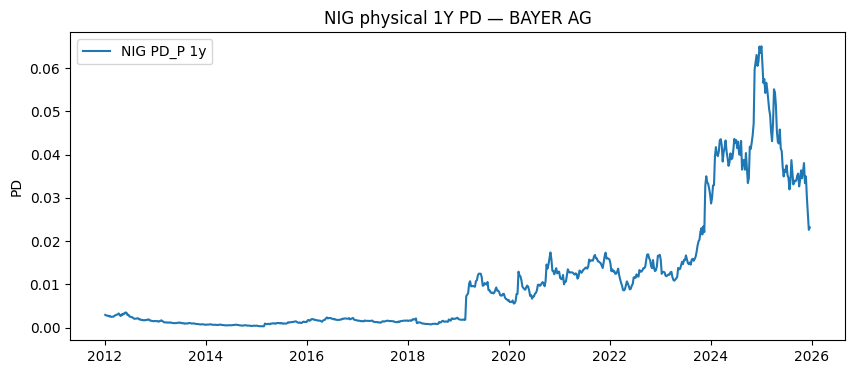

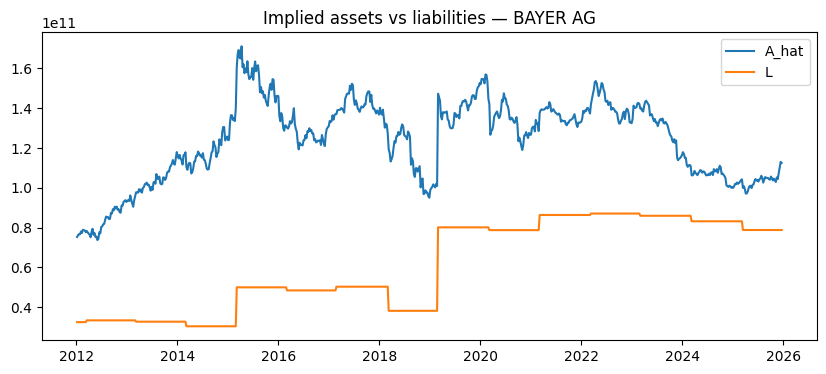

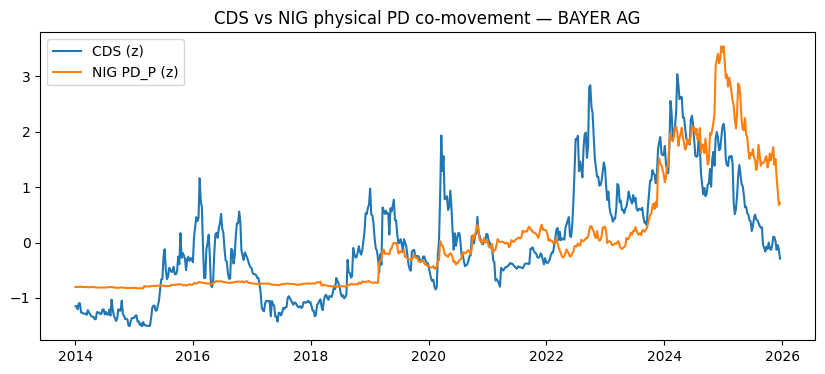

CDS / PD_P Spearman corr: 0.815257198957041


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(final_onefirm_nig["date"], final_onefirm_nig["PD_P_1y"], label="NIG PD_P 1y")
ax.set_title(f"NIG physical 1Y PD — {final_onefirm_nig['company'].iloc[0]}")
ax.set_ylabel("PD")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(final_onefirm_nig["date"], final_onefirm_nig["A_hat"], label="A_hat")
ax.plot(final_onefirm_nig["date"], final_onefirm_nig["L"], label="L")
ax.set_title(f"Implied assets vs liabilities — {final_onefirm_nig['company'].iloc[0]}")
ax.legend()
plt.show()

# PD vs CDS co-movement on common dates
cmp = final_onefirm_nig.dropna(subset=["cds", "PD_P_1y"]).copy()
if len(cmp):
    z_cds = (cmp["cds"] - cmp["cds"].mean()) / cmp["cds"].std(ddof=0)
    z_pd = (cmp["PD_P_1y"] - cmp["PD_P_1y"].mean()) / cmp["PD_P_1y"].std(ddof=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(cmp["date"], z_cds, label="CDS (z)")
    ax.plot(cmp["date"], z_pd, label="NIG PD_P (z)")
    ax.set_title(f"CDS vs NIG physical PD co-movement — {cmp['company'].iloc[0]}")
    ax.legend()
    plt.show()

    print("CDS / PD_P Spearman corr:", cmp[["cds", "PD_P_1y"]].corr(method="spearman").iloc[0, 1])
else:
    print("No overlapping non-missing CDS and PD dates.")

In [15]:
p_hat_annual = nig_weekly_to_annual(p_hat)

theta_q = []
ok_q = []
margin_theta = []
margin_theta1 = []

for _, row in final_onefirm_nig.iterrows():
    r_t = float(row["r"])
    try:
        th = solve_esscher_theta(p_hat_annual, r_t, tau=T_INV)
        ok_q.append(True)
        theta_q.append(th)
        margin_theta.append(p_hat_annual.alpha - abs(p_hat_annual.beta + th))
        margin_theta1.append(p_hat_annual.alpha - abs(p_hat_annual.beta + th + 1.0))
    except Exception:
        ok_q.append(False)
        theta_q.append(np.nan)
        margin_theta.append(np.nan)
        margin_theta1.append(np.nan)

q_diag = final_onefirm_nig[["date", "r"]].copy()
q_diag["theta_q"] = theta_q
q_diag["q_feasible"] = ok_q
q_diag["margin_theta"] = margin_theta
q_diag["margin_theta1"] = margin_theta1

print("Q-feasible share:", q_diag["q_feasible"].mean())
display(q_diag.head())
display(q_diag.tail())
print(q_diag[["margin_theta", "margin_theta1"]].describe())

Q-feasible share: 1.0


,date,r,theta_q,q_feasible,margin_theta,margin_theta1
0,2012-01-06,0.001873,-1.231198,True,1.019060,2.019060
1,2012-01-13,0.001492,-1.240353,True,1.009906,2.009906
2,2012-01-20,0.002094,-1.225877,True,1.024382,2.024382
3,2012-01-27,0.002112,-1.225443,True,1.024816,2.024816
4,2012-02-03,0.001579,-1.238261,True,1.011998,2.011998


,date,r,theta_q,q_feasible,margin_theta,margin_theta1
724,2025-11-21,0.019399,-0.767171,True,1.483087,2.016913
725,2025-11-28,0.019617,-0.760982,True,1.489277,2.010723
726,2025-12-05,0.019875,-0.753649,True,1.496610,2.003390
727,2025-12-12,0.020236,-0.743393,True,1.506865,1.993135
728,2025-12-19,0.020205,-0.744277,True,1.505982,1.994018


       margin_theta  margin_theta1
count    729.000000     729.000000
mean       1.069571       1.869656
std        0.353788       0.113600
min        0.775776       1.542807
25%        0.823927       1.813705
50%        0.916065       1.836909
75%        1.025522       1.968680
max        1.957193       2.215974
